In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.preprocessing import StandardScaler
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_numeric_std = StandardScaler().fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

# Clustering

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

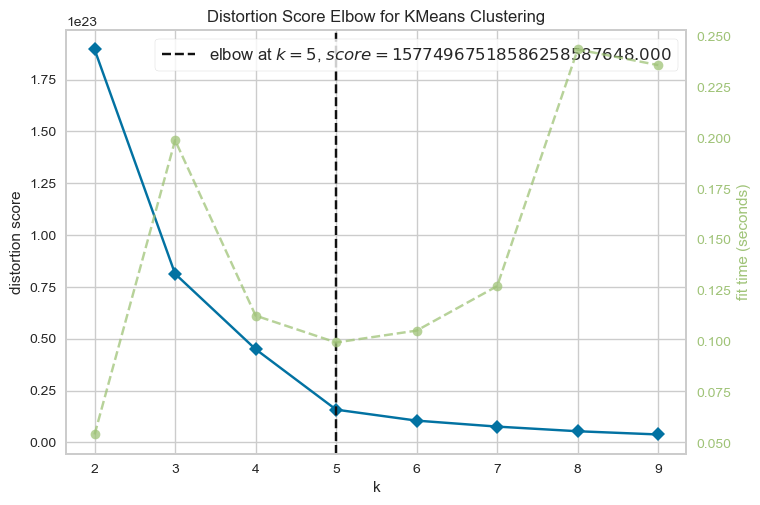

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: shape_VoxelVolume, Coefficient: 2.465133766676935


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: glrlm_GrayLevelVariance_CT_b20, Coefficient: 3.7227359532993085


...

Cluster 2: Most important feature: gldm_HighGrayLevelEmphasis_d_1_PET_b2, Coefficient: -2.783099582854299


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 3: Most important feature: glcm_Idmn_d_1_CT_c16, Coefficient: -1.613964352306142


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 4: Most important feature: gldm_LowGrayLevelEmphasis_d_1_CT_b20, Coefficient: 1.108442317463872


In [21]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [22]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [23]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns

MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [24]:
X_new

,shape_VoxelVolume,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_PET_b2,glcm_Idmn_d_1_CT_c16,gldm_LowGrayLevelEmphasis_d_1_CT_b20
0,16214.0,22.310788,21.825583,0.998252,0.000599
1,2863.0,20.557318,5.148096,0.996618,0.001257
2,28989.0,21.092104,7.728483,0.998604,0.000489
3,3337.0,22.786001,2.451603,0.996310,0.000823
4,5018.0,29.182742,6.265046,0.991932,0.001070
...,...,...,...,...,...
134,8321.0,4.906583,10.096743,0.998189,0.001330
135,25403.0,16.015030,8.800850,0.999244,0.000690
136,15322.0,24.706900,18.455750,0.997733,0.000791
137,18450.0,5.157909,9.256260,0.998547,0.001032


In [25]:
X_new_std

,shape_VoxelVolume,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_PET_b2,glcm_Idmn_d_1_CT_c16,gldm_LowGrayLevelEmphasis_d_1_CT_b20
0,-0.264205,-0.297212,0.412343,0.456785,-0.306479
1,-0.663896,-0.334997,-0.805985,-0.212800,-0.114198
2,0.118242,-0.323473,-0.617482,0.600782,-0.338675
3,-0.649706,-0.286972,-1.002970,-0.338902,-0.241171
4,-0.599382,-0.149131,-0.724390,-2.132062,-0.168890
...,...,...,...,...,...
134,-0.500499,-0.672249,-0.444475,0.431157,-0.092868
135,0.010887,-0.432877,-0.539143,0.863170,-0.280084
136,-0.290909,-0.245579,0.166169,0.243992,-0.250509
137,-0.197266,-0.666834,-0.505875,0.577711,-0.180016


In [26]:
MAASTRO_new

,shape_VoxelVolume,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_PET_b2,glcm_Idmn_d_1_CT_c16,gldm_LowGrayLevelEmphasis_d_1_CT_b20
0,38115.0,14.212485,27.358074,0.998319,0.000731
1,17918.0,54.975356,7.053856,0.998668,0.001905
2,17475.0,27.032891,16.053047,0.997797,0.000643
3,12512.0,146.781623,7.982976,0.995999,0.009286
4,28361.0,9.468732,9.935263,0.999010,0.000503
...,...,...,...,...,...
94,12865.0,40.637943,75.598756,0.998680,0.000654
95,18413.0,143.812625,14.466573,0.992922,0.003114
96,35439.0,22.317077,8.775756,0.998150,0.000405
97,26221.0,20.533289,16.990771,0.998636,0.000548


In [27]:
MAASTRO_new_std

,shape_VoxelVolume,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_PET_b2,glcm_Idmn_d_1_CT_c16,gldm_LowGrayLevelEmphasis_d_1_CT_b20
0,0.391448,-0.471720,0.816504,0.484244,-0.268092
1,-0.213192,0.406665,-0.666765,0.627266,0.075051
2,-0.226455,-0.195457,-0.009354,0.270288,-0.293783
3,-0.375033,2.384966,-0.598891,-0.466015,2.230994
4,0.099441,-0.573941,-0.456272,0.767202,-0.334554
...,...,...,...,...,...
94,-0.364465,0.097713,4.340597,0.632013,-0.290362
95,-0.198373,2.320988,-0.125249,-1.726571,0.428092
96,0.311336,-0.297077,-0.540977,0.414778,-0.363174
97,0.035376,-0.335515,0.059149,0.614016,-0.321504


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 18:32:19,315] A new study created in memory with name: no-name-32aa950e-2970-4cd2-81dd-3e212fde5027
python(24995) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-16 18:32:19,944] A new study created in memory with name: no-name-7a70a380-da58-462a-b8dd-7d680122d849


Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.4372623574144487
Fold 5 C-index: 0.463519313304721
[I 2024-04-16 18:32:19,917] Trial 0 finished with value: 0.5317846748138111 and parameters: {}. Best is trial 0 with value: 0.5317846748138111.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5317846748138111], datetime_start=datetime.datetime(2024, 4, 16, 18, 32, 19, 527867), datetime_complete=datetime.datetime(2024, 4, 16, 18, 32, 19, 916727), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5317846748138111


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2684954755577373
Fold 2 IBS: 0.228827136469355
Fold 3 IBS: 0.194550891243088
Fold 4 IBS: 0.3072511476861805
Fold 5 IBS: 0.24773507603319367
[I 2024-04-16 18:32:20,341] Trial 0 finished with value: 0.2493719453979109 and parameters: {}. Best is trial 0 with value: 0.2493719453979109.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2493719453979109], datetime_start=datetime.datetime(2024, 4, 16, 18, 32, 20, 9768), datetime_complete=datetime.datetime(2024, 4, 16, 18, 32, 20, 341341), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2493719453979109


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.532
train_ibs:  0.249


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.532
IBS score: 0.232


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 18:32:20,547] A new study created in memory with name: no-name-ab1e4762-c1fa-4850-93b7-0ed1c98301e1


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.4721115537848606
Fold 2 C-index: 0.6841085271317829


[I 2024-04-16 18:32:20,725] A new study created in memory with name: no-name-5a8cc59d-2786-4941-a837-c8cbbe18c873


Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.4448669201520912
Fold 5 C-index: 0.44849785407725323
[I 2024-04-16 18:32:20,721] Trial 0 finished with value: 0.5690659071994103 and parameters: {}. Best is trial 0 with value: 0.5690659071994103.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5690659071994103], datetime_start=datetime.datetime(2024, 4, 16, 18, 32, 20, 611200), datetime_complete=datetime.datetime(2024, 4, 16, 18, 32, 20, 721066), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5690659071994103


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2472471001477872
Fold 2 IBS: 0.2320398805496421
Fold 3 IBS: 0.22898184551808795
Fold 4 IBS: 0.24197477785524013
Fold 5 IBS: 0.22939559526928144
[I 2024-04-16 18:32:21,038] Trial 0 finished with value: 0.23592783986800775 and parameters: {}. Best is trial 0 with value: 0.23592783986800775.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592783986800775], datetime_start=datetime.datetime(2024, 4, 16, 18, 32, 20, 778227), datetime_complete=datetime.datetime(2024, 4, 16, 18, 32, 21, 37999), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592783986800775


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.569
train_ibs:  0.236


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.565


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 18:32:21,539] A new study created in memory with name: no-name-2e1e0f2b-6234-4612-9dcc-ec9851628198


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-16 18:32:21,800] A new study created in memory with name: no-name-45bc2672-a955-4b16-93b8-0cf66df8a2ae


Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.463519313304721
[I 2024-04-16 18:32:21,791] Trial 0 finished with value: 0.5658784644209087 and parameters: {}. Best is trial 0 with value: 0.5658784644209087.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5658784644209087], datetime_start=datetime.datetime(2024, 4, 16, 18, 32, 21, 569320), datetime_complete=datetime.datetime(2024, 4, 16, 18, 32, 21, 791446), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5658784644209087


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.267482779006714
Fold 2 IBS: 0.22555697638378489
Fold 3 IBS: 0.2181915391651773
Fold 4 IBS: 0.3059972103011284
Fold 5 IBS: 0.2472965877156562
[I 2024-04-16 18:32:22,071] Trial 0 finished with value: 0.25290501851449215 and parameters: {}. Best is trial 0 with value: 0.25290501851449215.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.25290501851449215], datetime_start=datetime.datetime(2024, 4, 16, 18, 32, 21, 832807), datetime_complete=datetime.datetime(2024, 4, 16, 18, 32, 22, 70957), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.25290501851449215


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.566
train_ibs:  0.253


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.557


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.226


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 18:32:22,302] A new study created in memory with name: no-name-f20e8096-e298-4641-b44e-ae0e8aeab0f0


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7617021276595745
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.463519313304721
[I 2024-04-16 18:32:22,573] Trial 0 finished with value: 0.566729528250696 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.566729528250696.
Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.774468085106383
Fold 4 C-index: 0.4448669201520912
Fold 5 C-index: 0.463519313304721
[I 2024-04-16 18:32:22,780] Trial 1 finished with value: 0.5700431760138219 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.5700431760138219.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7787234042553192
Fold 4 C-index: 0.4448669201520912
Fold 5 C-index: 0.463519313304721
[I 2024-04-16 18:32:23,027] Trial 2 finished with value: 0.575675116337633 and parameters: {'l1_ratio': 0.22692876841884668}. Best

Fold 5 C-index: 0.463519313304721
[I 2024-04-16 18:32:27,134] Trial 24 finished with value: 0.5748240525078459 and parameters: {'l1_ratio': 0.19621932764719313}. Best is trial 13 with value: 0.5822044990389368.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7787234042553192
Fold 4 C-index: 0.45627376425855515
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 18:32:27,221] Trial 25 finished with value: 0.5770981160602134 and parameters: {'l1_ratio': 0.07330522822697523}. Best is trial 13 with value: 0.5822044990389368.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.774468085106383
Fold 4 C-index: 0.4448669201520912
Fold 5 C-index: 0.463519313304721
[I 2024-04-16 18:32:27,388] Trial 26 finished with value: 0.5748240525078459 and parameters: {'l1_ratio': 0.20309774849254153}. Best is trial 13 with value: 0.5822044990389368.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7131782945736435
Fold 3 C-inde

Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.774468085106383
Fold 4 C-index: 0.4448669201520912
Fold 5 C-index: 0.463519313304721
[I 2024-04-16 18:32:31,623] Trial 49 finished with value: 0.5700431760138219 and parameters: {'l1_ratio': 0.41420721673326216}. Best is trial 13 with value: 0.5822044990389368.
Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7702127659574468
Fold 4 C-index: 0.4448669201520912
Fold 5 C-index: 0.463519313304721
[I 2024-04-16 18:32:31,976] Trial 50 finished with value: 0.5691921121840346 and parameters: {'l1_ratio': 0.47241766561900594}. Best is trial 13 with value: 0.5822044990389368.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.8
Fold 4 C-index: 0.45627376425855515
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 18:32:32,269] Trial 51 finished with value: 0.5813534352091496 and parameters: {'l1_ratio': 0.006012844952470507}. Best is 

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.26751397842974384
Fold 2 IBS: 0.22582676532399884
Fold 3 IBS: 0.21850531479749313
Fold 4 IBS: 0.30591152481759015
Fold 5 IBS: 0.24726583363283852
[I 2024-04-16 18:32:40,703] Trial 0 finished with value: 0.2530046834003329 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.2530046834003329.
Fold 1 IBS: 0.2676255832742071
Fold 2 IBS: 0.22716855078425424
Fold 3 IBS: 0.21969724985632727
Fold 4 IBS: 0.3060333747004132
Fold 5 IBS: 0.24718549971052647
[I 2024-04-16 18:32:41,085] Trial 1 finished with value: 0.25354205166514565 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.2530046834003329.
Fold 1 IBS: 0.24709071705881375
Fold 2 IBS: 0.22761361819251108
Fold 3 IBS: 0.22011760203034395
Fold 4 IBS: 0.30602423190710376
Fold 5 IBS: 0.24714404117813166
[I 2024-04-16 18:32:41,520] Trial 2 finished with value: 0.24959804207338082 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.24959804207338

Fold 3 IBS: 0.22018121599372537
Fold 4 IBS: 0.30611211345605055
Fold 5 IBS: 0.24713015558552526
[I 2024-04-16 18:32:48,024] Trial 25 finished with value: 0.24963800234106706 and parameters: {'l1_ratio': 0.21973436884995384}. Best is trial 10 with value: 0.23516859457203756.
Fold 1 IBS: 0.26755840153367283
Fold 2 IBS: 0.22679623550461628
Fold 3 IBS: 0.21935603349257882
Fold 4 IBS: 0.30601765091415634
Fold 5 IBS: 0.24721101412661875
[I 2024-04-16 18:32:48,377] Trial 26 finished with value: 0.2533878671143286 and parameters: {'l1_ratio': 0.3527001258697712}. Best is trial 10 with value: 0.23516859457203756.
Fold 1 IBS: 0.24708408660515097
Fold 2 IBS: 0.22868437184207124
Fold 3 IBS: 0.22108621600916964
Fold 4 IBS: 0.3060324468823464
Fold 5 IBS: 0.23109046074625672
[I 2024-04-16 18:32:48,572] Trial 27 finished with value: 0.24679551641699898 and parameters: {'l1_ratio': 0.13360026443673156}. Best is trial 10 with value: 0.23516859457203756.
Fold 1 IBS: 0.24709841601425422
Fold 2 IBS: 0.2293

Fold 3 IBS: 0.21864779811587745
Fold 4 IBS: 0.3059881213763438
Fold 5 IBS: 0.24723225789854336
[I 2024-04-16 18:32:54,655] Trial 50 finished with value: 0.2530771427246915 and parameters: {'l1_ratio': 0.6064718647459368}. Best is trial 10 with value: 0.23516859457203756.
Fold 1 IBS: 0.24709740916263545
Fold 2 IBS: 0.229325237624488
Fold 3 IBS: 0.22182427395591856
Fold 4 IBS: 0.24684209664224005
Fold 5 IBS: 0.23078507166494444
[I 2024-04-16 18:32:54,777] Trial 51 finished with value: 0.2351748178100453 and parameters: {'l1_ratio': 0.0961087213112333}. Best is trial 10 with value: 0.23516859457203756.
Fold 1 IBS: 0.24715094098937754
Fold 2 IBS: 0.23057362938454892
Fold 3 IBS: 0.22389847595574144
Fold 4 IBS: 0.24445438840817077
Fold 5 IBS: 0.23017113114850266
[I 2024-04-16 18:32:54,914] Trial 52 finished with value: 0.23524971317726825 and parameters: {'l1_ratio': 0.04325105622136559}. Best is trial 10 with value: 0.23516859457203756.
Fold 1 IBS: 0.24710086324841596
Fold 2 IBS: 0.22943796

Fold 1 IBS: 0.2471749087054557
Fold 2 IBS: 0.23098560264301224
Fold 3 IBS: 0.22489311068387244
Fold 4 IBS: 0.24372841090133093
Fold 5 IBS: 0.22996051886015373
[I 2024-04-16 18:33:00,483] Trial 75 finished with value: 0.235348510358765 and parameters: {'l1_ratio': 0.029573392490478932}. Best is trial 10 with value: 0.23516859457203756.
Fold 1 IBS: 0.24710981069070037
Fold 2 IBS: 0.22969378291755824
Fold 3 IBS: 0.2223303158951783
Fold 4 IBS: 0.24610378120754092
Fold 5 IBS: 0.2306069335406986
[I 2024-04-16 18:33:00,652] Trial 76 finished with value: 0.2351689248503353 and parameters: {'l1_ratio': 0.07827240310100005}. Best is trial 10 with value: 0.23516859457203756.
Fold 1 IBS: 0.24708208065159556
Fold 2 IBS: 0.22842513498016498
Fold 3 IBS: 0.22082798198882503
Fold 4 IBS: 0.3060509532123764
Fold 5 IBS: 0.23121282269514806
[I 2024-04-16 18:33:00,817] Trial 77 finished with value: 0.24671979470562203 and parameters: {'l1_ratio': 0.15186124650060323}. Best is trial 10 with value: 0.23516859

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.582
train_ibs:  0.235


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.004533947374774427)

test_cindex : 0.566


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.0821645933226833)

test_ibs:  0.227


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 18:33:05,542] A new study created in memory with name: no-name-749e44de-0d63-4c8d-affb-27605a62b6cf


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.46215139442231074
Fold 2 C-index: 0.5968992248062015
Fold 3 C-index: 0.548936170212766
Fold 4 C-index: 0.48859315589353614
Fold 5 C-index: 0.44206008583690987
[I 2024-04-16 18:33:10,557] Trial 0 finished with value: 0.5077280062343448 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5077280062343448.
Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6212765957446809
Fold 4 C-index: 0.5513307984790875
Fold 5 C-index: 0.43776824034334766
[I 2024-04-16 18:33:14,236] Trial 1 finished with value: 0.5340149644624519 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.752009792374571

Fold 4 C-index: 0.5779467680608364
Fold 5 C-index: 0.5150214592274678
[I 2024-04-16 18:33:45,158] Trial 15 finished with value: 0.6264471070853379 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 17, 'min_samples_leaf': 8, 'max_depth': 1, 'n_estimators': 383, 'oob_score': True, 'max_samples': 0.4747428535255964, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.02047504770072374, 'warm_start': True}. Best is trial 14 with value: 0.6278533429149133.
Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.7868217054263565
Fold 3 C-index: 0.7319148936170212
Fold 4 C-index: 0.526615969581749
Fold 5 C-index: 0.5021459227467812
[I 2024-04-16 18:33:48,340] Trial 16 finished with value: 0.5987427261628279 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 16, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 498, 'oob_score': True, 'max_samples': 0.36871324569404207, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.00016637357953819265, 'warm_start': True}. Best 

Fold 3 C-index: 0.8085106382978723
Fold 4 C-index: 0.7034220532319392
Fold 5 C-index: 0.6351931330472103
[I 2024-04-16 18:34:25,450] Trial 30 finished with value: 0.6935407954166551 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 3, 'n_estimators': 340, 'oob_score': True, 'max_samples': 0.852212471165956, 'max_features': None, 'min_weight_fraction_leaf': 0.07917932748301856, 'warm_start': True}. Best is trial 29 with value: 0.7414047946313312.
Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.7868217054263565
Fold 3 C-index: 0.8085106382978723
Fold 4 C-index: 0.7110266159695817
Fold 5 C-index: 0.6523605150214592
[I 2024-04-16 18:34:27,097] Trial 31 finished with value: 0.6961263650625759 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 3, 'n_estimators': 343, 'oob_score': True, 'max_samples': 0.8756489987799058, 'max_features': None, 'min_weight_fraction_leaf': 0.08382555077369214,

...

Fold 1 IBS: 0.246386460438482
Fold 2 IBS: 0.23218899742898796
Fold 3 IBS: 0.22946758410602397
Fold 4 IBS: 0.24118772219117468
Fold 5 IBS: 0.2303071920630508
[I 2024-04-16 18:36:44,307] Trial 32 finished with value: 0.2359075912455439 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 8, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 175, 'oob_score': True, 'max_samples': 0.20444340416617043, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.19558060234973634}. Best is trial 27 with value: 0.23583547084615547.
Fold 1 IBS: 0.24684478929600995
Fold 2 IBS: 0.2322329224950302
Fold 3 IBS: 0.23005427140610996
Fold 4 IBS: 0.2412308304074783
Fold 5 IBS: 0.2301271605653773
[I 2024-04-16 18:36:48,047] Trial 33 finished with value: 0.23609799483400112 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 235, 'oob_score': True, 'max_samples': 0.23980153995474307, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 5 IBS: 0.22978676956550373
[I 2024-04-16 18:37:30,592] Trial 47 finished with value: 0.23575678560731528 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 160, 'oob_score': True, 'max_samples': 0.13434415907111946, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10612603041708193}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24757897353687755
Fold 2 IBS: 0.2320725752850252
Fold 3 IBS: 0.2299544780683508
Fold 4 IBS: 0.24154478404388094
Fold 5 IBS: 0.23016145399352744
[I 2024-04-16 18:37:31,785] Trial 48 finished with value: 0.2362624529855324 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 86, 'oob_score': True, 'max_samples': 0.12964207163685623, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10203918387448863}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24671151151924972
Fold 2 IBS: 0.2321

Fold 1 IBS: 0.24631928839139375
Fold 2 IBS: 0.23211332325251055
Fold 3 IBS: 0.22987340393724426
Fold 4 IBS: 0.24110794902474542
Fold 5 IBS: 0.2296571564179856
[I 2024-04-16 18:37:56,729] Trial 63 finished with value: 0.2358142242047759 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 150, 'oob_score': True, 'max_samples': 0.10056089265752739, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.026471209866795242}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24648722835656947
Fold 2 IBS: 0.23206092276817514
Fold 3 IBS: 0.22928811947466984
Fold 4 IBS: 0.24128731957110403
Fold 5 IBS: 0.22992351169818162
[I 2024-04-16 18:37:57,997] Trial 64 finished with value: 0.23580942037374003 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 104, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fractio

Fold 5 IBS: 0.27388991680337776
[I 2024-04-16 18:38:22,053] Trial 78 finished with value: 0.2471490762104326 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 11, 'n_estimators': 171, 'oob_score': True, 'max_samples': 0.9147835512625551, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.13257772422273512}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24630596960013934
Fold 2 IBS: 0.23202892604980208
Fold 3 IBS: 0.23058361904315297
Fold 4 IBS: 0.24129573617042252
Fold 5 IBS: 0.2301768553877985
[I 2024-04-16 18:38:22,550] Trial 79 finished with value: 0.2360782212502631 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 12, 'n_estimators': 37, 'oob_score': True, 'max_samples': 0.2189744006895358, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17152888523323856}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24642825384745612
Fold 2 IBS: 0.2320

Fold 1 IBS: 0.24603980142682666
Fold 2 IBS: 0.23212293756683253
Fold 3 IBS: 0.22980177266109972
Fold 4 IBS: 0.24117019375096946
Fold 5 IBS: 0.23000323031974987
[I 2024-04-16 18:38:57,873] Trial 94 finished with value: 0.23582758714509566 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 186, 'oob_score': True, 'max_samples': 0.15211446012016716, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1336981908011637}. Best is trial 84 with value: 0.23572114547332967.
Fold 1 IBS: 0.24609144860992238
Fold 2 IBS: 0.23210462726436726
Fold 3 IBS: 0.23027168009436597
Fold 4 IBS: 0.24100241364516664
Fold 5 IBS: 0.2300638162943246
[I 2024-04-16 18:39:02,631] Trial 95 finished with value: 0.23590679718162938 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 489, 'oob_score': True, 'max_samples': 0.12627955102410032, 'max_features': 'auto', 'min_weight_fraction

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.794
train_ibs:  0.236


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=20, max_features='auto', max_leaf_nodes=11,
                     max_samples=0.9562416117071022, min_samples_leaf=2,
                     min_samples_split=9,
                     min_weight_fraction_leaf=0.013097521700076066,
                     n_estimators=99, random_state=123, warm_start=True)

test_cindex:  0.573


RandomSurvivalForest(max_depth=3, max_features='auto', max_leaf_nodes=11,
                     max_samples=0.1369774849788948, min_samples_leaf=2,
                     min_samples_split=20,
                     min_weight_fraction_leaf=0.07082006896114468,
                     n_estimators=186, oob_score=True, random_state=123)

test_ibs:  0.23


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 18:39:11,331] A new study created in memory with name: no-name-cfeedc3f-0024-4cfd-b871-16cfcfed6039


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5577689243027888
Fold 2 C-index: 0.7364341085271318
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.5475285171102662
Fold 5 C-index: 0.5064377682403434
[I 2024-04-16 18:39:12,253] Trial 0 finished with value: 0.6262296083169572 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6262296083169572.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 18:39:14,004] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.5697211155378487
Fold 2 C-index: 0.7538759689922481
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.42395437262357416
Fold 5 C-index: 0.5815450643776824
[I 2024-04-16 18:39:32,262] Trial 16 finished with value: 0.6130533468594621 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 16, 'min_samples_leaf': 19, 'max_depth': 20, 'n_estimators': 72, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.6368998676790889, 'min_weight_fraction_leaf': 0.23422488676293018}. Best is trial 8 with value: 0.6346285616184463.
Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.7191489361702128
Fold 4 C-index: 0.5779467680608364
Fold 5 C-index: 0.5321888412017167
[I 2024-04-16 18:39:32,713] Trial 17 finished with value: 0.6311368744962323 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 10, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 180, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.6195219123505976
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.6978723404255319
Fold 4 C-index: 0.5741444866920152
Fold 5 C-index: 0.5793991416309013
[I 2024-04-16 18:39:42,450] Trial 31 finished with value: 0.6306216847469409 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 10, 'max_depth': 12, 'n_estimators': 51, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.8055318350655486, 'min_weight_fraction_leaf': 0.12957495622736165}. Best is trial 23 with value: 0.6529146606242022.
Fold 1 C-index: 0.649402390438247
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.5760456273764258
Fold 5 C-index: 0.6072961373390557
[I 2024-04-16 18:39:42,747] Trial 32 finished with value: 0.657269596328453 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 6, 'min_samples_leaf': 11, 'max_depth': 10, 'n_estimators': 125, 'oob_score': False, 'warm_start': True, 'max_features'

...

Fold 1 IBS: 0.2465078211610681
Fold 2 IBS: 0.2296499616651633
Fold 3 IBS: 0.22561854250115249
Fold 4 IBS: 0.2424215499533287
Fold 5 IBS: 0.2313538569981253
[I 2024-04-16 18:41:00,660] Trial 30 finished with value: 0.23511034645576756 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 6, 'min_samples_leaf': 5, 'max_depth': 9, 'n_estimators': 90, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.3953061204548758, 'min_weight_fraction_leaf': 0.055332769416166314}. Best is trial 24 with value: 0.2339955505419295.
Fold 1 IBS: 0.24463644680823732
Fold 2 IBS: 0.2290193319147786
Fold 3 IBS: 0.224902088632948
Fold 4 IBS: 0.2439618812253637
Fold 5 IBS: 0.23140155193262874
[I 2024-04-16 18:41:01,781] Trial 31 finished with value: 0.23478426010279127 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 11, 'n_estimators': 124, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.63110971652225

Fold 2 IBS: 0.2306842480062196
Fold 3 IBS: 0.2351434594402525
Fold 4 IBS: 0.24123707588128265
Fold 5 IBS: 0.22974853580761176
[I 2024-04-16 18:41:13,485] Trial 45 finished with value: 0.23631131712724773 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 14, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 20, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.5586473886674701, 'min_weight_fraction_leaf': 0.04869951612195322}. Best is trial 44 with value: 0.23358013086946877.
Fold 1 IBS: 0.24366818930805276
Fold 2 IBS: 0.22786715447486752
Fold 3 IBS: 0.22558949171306097
Fold 4 IBS: 0.2429055149108531
Fold 5 IBS: 0.2287485109522979
[I 2024-04-16 18:41:13,745] Trial 46 finished with value: 0.23375577227182648 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 11, 'min_samples_leaf': 11, 'max_depth': 15, 'n_estimators': 21, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.7606258272321439, 'min_weight_fraction_le

Fold 1 IBS: 0.2432573354430918
Fold 2 IBS: 0.2304846744159247
Fold 3 IBS: 0.22273925436693703
Fold 4 IBS: 0.24347142828614102
Fold 5 IBS: 0.22939947422364693
[I 2024-04-16 18:41:24,600] Trial 60 finished with value: 0.23387043334714827 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 11, 'max_depth': 20, 'n_estimators': 16, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.963174115269939, 'min_weight_fraction_leaf': 0.005881250371646392}. Best is trial 44 with value: 0.23358013086946877.
Fold 1 IBS: 0.24439270484026193
Fold 2 IBS: 0.2325795346446554
Fold 3 IBS: 0.2280486847402182
Fold 4 IBS: 0.2452485109588804
Fold 5 IBS: 0.23079437724430676
[I 2024-04-16 18:41:24,834] Trial 61 finished with value: 0.23621276248566456 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 11, 'max_depth': 20, 'n_estimators': 1, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.951002262162

Fold 2 IBS: 0.2254105363640865
Fold 3 IBS: 0.2275472973178155
Fold 4 IBS: 0.24631650610396758
Fold 5 IBS: 0.2388346385306538
[I 2024-04-16 18:41:40,206] Trial 75 finished with value: 0.23590987471903002 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 8, 'min_samples_leaf': 7, 'max_depth': 18, 'n_estimators': 16, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8984709552389893, 'min_weight_fraction_leaf': 0.07855738724452986}. Best is trial 44 with value: 0.23358013086946877.
Fold 1 IBS: 0.24560221757955758
Fold 2 IBS: 0.229296840019422
Fold 3 IBS: 0.2273820095003296
Fold 4 IBS: 0.24340934801043904
Fold 5 IBS: 0.23196475510883208
[I 2024-04-16 18:41:42,842] Trial 76 finished with value: 0.23553103404371606 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 10, 'min_samples_leaf': 10, 'max_depth': 10, 'n_estimators': 229, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.9148545427091341, 'min_weight_fraction_

Fold 1 IBS: 0.24424724817270696
Fold 2 IBS: 0.225831177193504
Fold 3 IBS: 0.22420745509687937
Fold 4 IBS: 0.24333099936686392
Fold 5 IBS: 0.23317788241850887
[I 2024-04-16 18:41:58,443] Trial 90 finished with value: 0.23415895244969262 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 13, 'min_samples_leaf': 7, 'max_depth': 20, 'n_estimators': 61, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.8876369413836059, 'min_weight_fraction_leaf': 0.02948465721861602}. Best is trial 79 with value: 0.2323897099268454.
Fold 1 IBS: 0.24350890517071658
Fold 2 IBS: 0.22946791157238935
Fold 3 IBS: 0.2260901220493018
Fold 4 IBS: 0.2444841836786187
Fold 5 IBS: 0.23280675285341781
[I 2024-04-16 18:41:59,069] Trial 91 finished with value: 0.23527157506488888 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 9, 'min_samples_leaf': 6, 'max_depth': 19, 'n_estimators': 39, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.643298351550

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.668
train_ibs:  0.232


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=11, max_features=0.1, max_leaf_nodes=6,
                   max_samples=0.8471431037253887, min_samples_leaf=9,
                   min_samples_split=14,
                   min_weight_fraction_leaf=0.029782301162976206,
                   n_estimators=82, random_state=123, warm_start=True)

C-index score: 0.578


ExtraSurvivalTrees(max_depth=18, max_features=1, max_leaf_nodes=8,
                   max_samples=0.9721770593196245, min_samples_leaf=8,
                   min_samples_split=7,
                   min_weight_fraction_leaf=0.025792426974396016,
                   n_estimators=5, random_state=123)

IBS: 0.227


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 18:42:02,818] A new study created in memory with name: no-name-5e4f2e5f-6ca0-45a8-aa59-037122d44731


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 18:42:20,674] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 18:42:33,319] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 18:45:21,432] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.402356635584068, 'learning_rate': 0.04320515007344335, 'dropout_rate': 0.4821375662037144, 'n_estimators': 338, 'criterion': 'friedman_mse', 'ccp_alpha': 5.782673919726945, 'min_weight_fraction_leaf': 0.3780093996731174, 'max_features': 1, 'min_impurity_decrease': 4.1224286247713165e-05, 'validation_fraction': 0.3705130702856921, 'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 14}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 18:45:44,122] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.8084735022381804, 'learning_rate': 0.051554368700984315, 'dropout_rate': 0.7600297296847041, 'n_estimators': 485, 'criterion': 'friedman_mse', 'ccp_alpha': 1.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 18:48:14,658] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7290419373338021, 'learning_rate': 0.008509588429086327, 'dropout_rate': 0.8441717101825217, 'n_estimators': 96, 'criterion': 'squared_error', 'ccp_alpha': 4.233740780727753, 'min_weight_fraction_leaf': 0.32029463020494575, 'max_features': 1, 'min_impurity_decrease': 3.23815069163876e-06, 'validation_fraction': 0.3886651085109431, 'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 6}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 18:48:18,960] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.835623033509183, 'learning_rate': 0.0441170168532854, 'dropout_rate': 0.661659879615144, 'n_estimators': 170, 'criterion': 'friedman_mse', 'ccp_alpha': 5.46231

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 19:12:18,289] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 19:12:20,706] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 19:13:58,870] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-16 19:14:09,269] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 19:15:23,750] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 19:15:35,237] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 19:16:39,266] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 19:16:50,517] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 19:18:28,517] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 19:18:29,222] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.236


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=9.807641983846155,
                                 dropout_rate=0.3041663082077828,
                                 learning_rate=0.02932779416008757,
                                 max_depth=11, max_leaf_nodes=5,
                                 min_impurity_decrease=2.4449249473284515e-05,
                                 min_samples_leaf=11, min_samples_split=5,
                                 min_weight_fraction_leaf=0.34241486929243165,
                                 n_estimators=276, random_state=123,
                                 subsample=0.7268222670380755,
                                 validation_fraction=0.7379954057320357)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 19:19:55,074] A new study created in memory with name: no-name-15fb164d-4842-49ab-8083-bf637de6128d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4820717131474104
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.4524714828897338
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 19:19:56,093] Trial 0 finished with value: 0.578061406396578 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.578061406396578.
Fold 1 C-index: 0.4820717131474104
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.7914893617021277
Fold 4 C-index: 0.4524714828897338
Fold 5 C-index: 0.44206008583690987
[I 2024-04-16 19:20:03,731] Trial 1 finished with value: 0.5754789938315155 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.578061406396578.
Fold 1 C-index: 0.4940239043824701
Fold 2 C-index: 0.7325581395348837
Fold 3 C-index: 0.8042553191489362
Fold 4 

Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7914893617021277
Fold 4 C-index: 0.4600760456273764
Fold 5 C-index: 0.43776824034334766
[I 2024-04-16 19:20:39,650] Trial 19 finished with value: 0.5801039820747971 and parameters: {'subsample': 0.6184925197877589, 'dropout_rate': 0.9955936173170101, 'n_estimators': 113, 'learning_rate': 0.004296729375623993}. Best is trial 15 with value: 0.5916551271801895.
Fold 1 C-index: 0.5139442231075697
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.8127659574468085
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.45493562231759654
[I 2024-04-16 19:20:40,104] Trial 20 finished with value: 0.5895033286411264 and parameters: {'subsample': 0.38336553245352756, 'dropout_rate': 0.6215085983251084, 'n_estimators': 59, 'learning_rate': 0.017331004877487094}. Best is trial 15 with value: 0.5916551271801895.
Fold 1 C-index: 0.4820717131474104
Fold 2 C-index: 0.7209302325581395
Fold 3 C-index: 0.804255319148

Fold 4 C-index: 0.4524714828897338
Fold 5 C-index: 0.44206008583690987
[I 2024-04-16 19:20:50,634] Trial 38 finished with value: 0.581983616935668 and parameters: {'subsample': 0.30779763982822483, 'dropout_rate': 0.42731075662470547, 'n_estimators': 26, 'learning_rate': 0.027739490037737666}. Best is trial 22 with value: 0.5936796206778668.
Fold 1 C-index: 0.5139442231075697
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.8042553191489362
Fold 4 C-index: 0.45627376425855515
Fold 5 C-index: 0.44206008583690987
[I 2024-04-16 19:20:51,905] Trial 39 finished with value: 0.5890431125789213 and parameters: {'subsample': 0.40918246569128813, 'dropout_rate': 0.9401899519784009, 'n_estimators': 175, 'learning_rate': 0.01033884503473171}. Best is trial 22 with value: 0.5936796206778668.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.8042553191489362
Fold 4 C-index: 0.45627376425855515
Fold 5 C-index: 0.4334763948497854
[I 2024-04-16 19:20:52,331] T

...

Fold 4 IBS: 0.2875334543918373
Fold 5 IBS: 0.23755871135924625
[I 2024-04-16 19:25:23,189] Trial 19 finished with value: 0.239671761302552 and parameters: {'subsample': 0.6477795744201034, 'dropout_rate': 0.8173815053858949, 'n_estimators': 85, 'learning_rate': 0.03825176355689751}. Best is trial 17 with value: 0.23471910192373188.
Fold 1 IBS: 0.4382739213236326
Fold 2 IBS: 0.38449831136504387
Fold 3 IBS: 0.2007149492618969
Fold 4 IBS: 0.41163699089177797
Fold 5 IBS: 0.3745392639043742
[I 2024-04-16 19:25:26,236] Trial 20 finished with value: 0.3619326873493451 and parameters: {'subsample': 0.8995742447068862, 'dropout_rate': 0.6343004869297953, 'n_estimators': 339, 'learning_rate': 0.0817175642960023}. Best is trial 17 with value: 0.23471910192373188.
Fold 1 IBS: 0.25113074344088243
Fold 2 IBS: 0.217437263320738
Fold 3 IBS: 0.20484979047109428
Fold 4 IBS: 0.2713858596897568
Fold 5 IBS: 0.23213202688219076
[I 2024-04-16 19:25:27,013] Trial 21 finished with value: 0.23538713676093245 an

Fold 5 IBS: 0.23120217068950824
[I 2024-04-16 19:25:40,913] Trial 38 finished with value: 0.23486114111977213 and parameters: {'subsample': 0.7646371732718725, 'dropout_rate': 0.27166395709157576, 'n_estimators': 212, 'learning_rate': 0.007493646145877634}. Best is trial 23 with value: 0.2342021020160404.
Fold 1 IBS: 0.24708756535800433
Fold 2 IBS: 0.2240389429065559
Fold 3 IBS: 0.21788719207021098
Fold 4 IBS: 0.25601721177845416
Fold 5 IBS: 0.2308000766048219
[I 2024-04-16 19:25:42,341] Trial 39 finished with value: 0.23516619774360947 and parameters: {'subsample': 0.6944937660864701, 'dropout_rate': 0.4487755788535598, 'n_estimators': 198, 'learning_rate': 0.005835998719509138}. Best is trial 23 with value: 0.2342021020160404.
Fold 1 IBS: 0.2807056982454691
Fold 2 IBS: 0.21499822475007369
Fold 3 IBS: 0.19130033286818127
Fold 4 IBS: 0.308943660611517
Fold 5 IBS: 0.25492185016207075
[I 2024-04-16 19:25:45,150] Trial 40 finished with value: 0.2501739533274624 and parameters: {'subsample

Fold 2 IBS: 0.21651535505881267
Fold 3 IBS: 0.2043031664485449
Fold 4 IBS: 0.2739738249501608
Fold 5 IBS: 0.23274401509145476
[I 2024-04-16 19:26:03,918] Trial 58 finished with value: 0.2358509176733306 and parameters: {'subsample': 0.914771440902963, 'dropout_rate': 0.18883347849922658, 'n_estimators': 49, 'learning_rate': 0.05058367078821971}. Best is trial 23 with value: 0.2342021020160404.
Fold 1 IBS: 0.24910498540709566
Fold 2 IBS: 0.22283125016057131
Fold 3 IBS: 0.21067960115013495
Fold 4 IBS: 0.2943828731979811
Fold 5 IBS: 0.24370990644156648
[I 2024-04-16 19:26:04,387] Trial 59 finished with value: 0.2441417232714699 and parameters: {'subsample': 0.14522006252948272, 'dropout_rate': 0.3403595120202195, 'n_estimators': 80, 'learning_rate': 0.045948517656638516}. Best is trial 23 with value: 0.2342021020160404.
Fold 1 IBS: 0.24714620758631173
Fold 2 IBS: 0.22689962294180907
Fold 3 IBS: 0.21900556589203332
Fold 4 IBS: 0.2488524849233669
Fold 5 IBS: 0.22960486837282218
[I 2024-04-1

Fold 4 IBS: 0.2612528949061071
Fold 5 IBS: 0.23105859733110043
[I 2024-04-16 19:26:09,747] Trial 77 finished with value: 0.23500612815498126 and parameters: {'subsample': 0.8186706177219771, 'dropout_rate': 0.2573486790984076, 'n_estimators': 47, 'learning_rate': 0.03343695191083501}. Best is trial 72 with value: 0.23402974855249842.
Fold 1 IBS: 0.2477231472402647
Fold 2 IBS: 0.22443120368883024
Fold 3 IBS: 0.2152638032491601
Fold 4 IBS: 0.25503467568459814
Fold 5 IBS: 0.23016288535582807
[I 2024-04-16 19:26:09,979] Trial 78 finished with value: 0.23452314304373628 and parameters: {'subsample': 0.8676672301682798, 'dropout_rate': 0.3241499758838411, 'n_estimators': 32, 'learning_rate': 0.03682749035405441}. Best is trial 72 with value: 0.23402974855249842.
Fold 1 IBS: 0.2498962684593748
Fold 2 IBS: 0.21842886514473112
Fold 3 IBS: 0.20546026303319598
Fold 4 IBS: 0.26760555142262815
Fold 5 IBS: 0.23115817859989637
[I 2024-04-16 19:26:10,521] Trial 79 finished with value: 0.23450982533196

Fold 1 IBS: 0.24710553707273825
Fold 2 IBS: 0.22776258182970682
Fold 3 IBS: 0.22147190000582892
Fold 4 IBS: 0.2479959989247359
Fold 5 IBS: 0.2297119636616793
[I 2024-04-16 19:26:17,689] Trial 97 finished with value: 0.23480959629893783 and parameters: {'subsample': 0.9028918516482115, 'dropout_rate': 0.6519942420501896, 'n_estimators': 53, 'learning_rate': 0.010761185121502882}. Best is trial 88 with value: 0.2338949595023382.
Fold 1 IBS: 0.2507388922499683
Fold 2 IBS: 0.2175162923743785
Fold 3 IBS: 0.20220455539916513
Fold 4 IBS: 0.27104284462191036
Fold 5 IBS: 0.2317350102237016
[I 2024-04-16 19:26:18,255] Trial 98 finished with value: 0.2346475189738248 and parameters: {'subsample': 0.9528226057785423, 'dropout_rate': 0.6064253063724393, 'n_estimators': 93, 'learning_rate': 0.023349597305590122}. Best is trial 88 with value: 0.2338949595023382.
Fold 1 IBS: 0.25024461948948923
Fold 2 IBS: 0.2182955831191044
Fold 3 IBS: 0.20645187481569235
Fold 4 IBS: 0.26975283128139177
Fold 5 IBS: 0

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.597
train_ibs:  0.234


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5340794382591971,
                                              learning_rate=0.0484236524769358,
                                              n_estimators=419,
                                              random_state=123,
                                              subsample=0.32095204334381583)

C-index score: 0.567


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.4740692363247232,
                                              learning_rate=0.030008392324213328,
                                              n_estimators=43, random_state=123,
                                              subsample=0.9367342646331982)

IBS: 0.225


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Result

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.794,1.0
ExtraSurvivalTrees,0.668,2.0
ComponentwiseGradientBoosting,0.597,3.0
CoxElastic,0.582,4.0
CoxRidge,0.569,5.0
CoxLasso,0.566,6.0
CoxPH,0.532,7.0
GradientBoosting,0.500,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.232,1.0
ComponentwiseGradientBoosting,0.234,2.0
CoxElastic,0.235,3.0
CoxRidge,0.236,5.0
Randomsurvivalforest,0.236,5.0
GradientBoosting,0.236,5.0
CoxPH,0.249,7.0
CoxLasso,0.253,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.578,1.0
Randomsurvivalforest,0.573,2.0
ComponentwiseGradientBoosting,0.567,3.0
CoxElastic,0.566,4.0
CoxRidge,0.565,5.0
CoxLasso,0.557,6.0
CoxPH,0.532,7.0
GradientBoosting,0.500,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.225,1.0
CoxLasso,0.226,2.0
CoxElastic,0.227,3.5
ExtraSurvivalTrees,0.227,3.5
CoxRidge,0.229,5.5
GradientBoosting,0.229,5.5
Randomsurvivalforest,0.230,7.0
CoxPH,0.232,8.0


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/dfs/standard/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file namess
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_dfs_standard_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-16
